In [1]:
! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf


   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
    --------------------------------------- 0.3/18.9 MB ? eta -:--:--
    --------------------------------------- 0.3/18.9 MB ? eta -:--:--
    --------------------------------------- 0.3/18.9 MB ? eta -:--:--
    --------------------------------------- 0.3/18.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/18.9 MB 273.6 kB/s eta 0:01:08
   - -------------------------------------- 0.8/18.9 MB 438.9 kB/s eta 0:00:42
   - -------------------------------------- 0.8/18.9 MB 438.9 kB/s eta 0:00:42
   -- ------------------------------------- 1.0/18.9 MB 506.9 kB/s eta 0:00:36
   -- ------------------------------------- 1.0/18.9 M

In [ ]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

c:\Users\megha\anaconda3\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [4]:
load_dotenv()

False

In [63]:
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()

In [64]:
len(docs)

392

In [65]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [66]:
len(chunks)

973

In [67]:
embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
vector_store = FAISS.from_documents(chunks, embeddings)

In [68]:
vector_store

In [69]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [70]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [71]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [72]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [73]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [74]:
tool_node = ToolNode(tools)

In [75]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

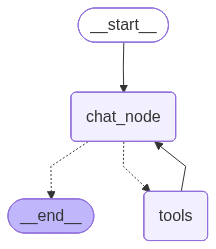

In [76]:
chatbot

In [ ]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)

In [80]:
print(result['messages'][-1].content)

To find the ideal value of \( K \) in the k-nearest neighbors (k-NN) algorithm, follow these steps:

1. **Understand the Role of \( K \)**: The parameter \( K \) represents the number of nearest neighbors to consider when making predictions. A small \( K \) can lead to a model that is sensitive to noise in the data, whereas a large \( K \) can smooth out the decision boundary too much, potentially leading to underfitting.

2. **Choose a Parameter Selection Method**: The most common method for selecting the ideal \( K \) is through grid search, which involves trying a range of values for \( K \) and evaluating their performance. You can use cross-validation to assess the performance of each \( K \).

3. **Set Up Cross-Validation**: Divide your dataset into training and testing subsets, and then perform k-fold cross-validation. This involves splitting the training set into \( K \) smaller sets. For each unique group, you will:
   - Train your model using the other \( K - 1 \) sets.
   - 